<a href="https://colab.research.google.com/github/DDanso98/assignment-8/blob/main/Assignment_8_DDanso.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment 8: Supervised Learning Classification | Dominic Danso - September 13, 2026**

In [4]:
#Import Relevant Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay)

The focus of this project is to analyze and evaluate the Heart Failure Prediction Dataset, which captures 11 clinical health markers, many of which being indicators of possible heart disease. Through the exploration & transformation of this data, supervised machine learning models can then be trained to predict patient heart disease with a degree of certainty to be determined below.

**Attribute Information**
1.   **Age**: age of the patient [years]
2.   **Sex**: sex of the patient [M: Male, F: Female]
1.   **ChestPainType**: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
1.   **RestingBP**: resting blood pressure [mm Hg]
1.   **Cholesterol**: serum cholesterol [mm/dl]
1.   **FastingBS**: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]
2.   **RestingECG**: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]
2.   **MaxHR**: maximum heart rate achieved [Numeric value between 60 and 202]
2.   **ExerciseAngina**: exercise-induced angina [Y: Yes, N: No]
2.   **Oldpeak**: oldpeak = ST [Numeric value measured in depression]
1.   **ST_Slope**: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
2.   **HeartDisease**: output class [1: heart disease, 0: Normal]

**Task 1: Dataset Selection and Preprocessing**

`Initial Data Overview`

In [5]:
#Load the Data
df = pd.read_csv('heart.csv')

#Print 'df' First Five Rows
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [6]:
#Print 'df' Final Five Rows
df.tail()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


In [7]:
#Examine Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [8]:
#Examine Data Summary Statistics
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


Based on the dataset 'Non-Null Count' initial exploration reveals that there are no missing values requiring inputation. However, when evaluating the summary statistics, the following two columns include unrealistic/impossible minimum values of zero:
*   RestingBP
*   Cholesterol

What this suggests is that any zeros entered in either of these columns were added in place of missing values and if left untouched, would inaccurately skew data analysis and model training. As such, the necessary steps to replace applicable values below during data cleaning & transformation.

`Check for & Handle Duplicate Rows`

In [9]:
#Check Data for Duplicate Rows
n_duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {n_duplicates}")

Duplicate rows found: 0


`Check for & Handle Missing Values`

In [10]:
#Handle Missing Values
print("Null values per column:")
print(df.isnull().sum())

Null values per column:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [11]:
#Handle Disguised Missing Values
print("Rows with Cholesterol == 0:", (df["Cholesterol"] == 0).sum())
print("Rows with RestingBP == 0:", (df["RestingBP"] == 0).sum())

Rows with Cholesterol == 0: 172
Rows with RestingBP == 0: 1


In [12]:
#Replace Implausible 0s with NaN
df["RestingBP"] = df["RestingBP"].replace(0, np.nan)
df["Cholesterol"] = df["Cholesterol"].replace(0, np.nan)

In order to replace the relevant values in the 'RestingBP' & 'Cholesterol' columns, any values of zero must first be correctly flagged as null (`np.nan`) prior to inputation.

Inputation will be done using respective column medians as opposed to the mean considering that the mean is more sensitive to data outliers.

In [13]:
#Impute Values Using Respective Column Median
df["RestingBP"] = df["RestingBP"].fillna(df["RestingBP"].median())
df["Cholesterol"] = df["Cholesterol"].fillna(df["Cholesterol"].median())

print("After imputation, remaining zeros:")
print("RestingBP == 0:", (df["RestingBP"] == 0).sum())
print("Cholesterol == 0:", (df["Cholesterol"] == 0).sum())

After imputation, remaining zeros:
RestingBP == 0: 0
Cholesterol == 0: 0


`Categorical Variable Encoding`

For model training & testing, variable encoding will be performed on the following string columns:
*   Sex
*   ExerciseAngina
*   ChestPainType
*   RestingECG
*   ST_Slope

A deliberate combination of encoding techniques will be employed with label encoding for true binary columns (Sex & ExerciseAngina) and one-hot encoding for nominal columns to avoid implying any false ranking between categories (ChestPainType, RestingECG, & ST_Slope).


In [14]:
#Binary Categorical Variables
binary_cols = ["Sex", "ExerciseAngina"]
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [15]:
#Nominal Categorical Variables
nominal_cols = ["ChestPainType", "RestingECG", "ST_Slope"]
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

print("Columns after encoding:")
print(df.columns.tolist())

Columns after encoding:
['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'HeartDisease', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Flat', 'ST_Slope_Up']


In [16]:
df

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,1,140.0,289.0,0,172,0,0.0,0,True,False,False,True,False,False,True
1,49,0,160.0,180.0,0,156,0,1.0,1,False,True,False,True,False,True,False
2,37,1,130.0,283.0,0,98,0,0.0,0,True,False,False,False,True,False,True
3,48,0,138.0,214.0,0,108,1,1.5,1,False,False,False,True,False,True,False
4,54,1,150.0,195.0,0,122,0,0.0,0,False,True,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,1,110.0,264.0,0,132,0,1.2,1,False,False,True,True,False,True,False
914,68,1,144.0,193.0,1,141,0,3.4,1,False,False,False,True,False,True,False
915,57,1,130.0,131.0,0,115,1,1.2,1,False,False,False,True,False,True,False
916,57,0,130.0,236.0,0,174,0,0.0,1,True,False,False,False,False,True,False


`Split Data Into Training/Testing Sets`

In [17]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y #preserve class balance in both splits
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Train size: 734 | Test size: 184


**Task 2: Exploratory Data Analysis (EDA)**

In [18]:
#Set Theme to Keep Plots Readable
sns.set_theme(style="whitegrid")

`Data Visualizations`

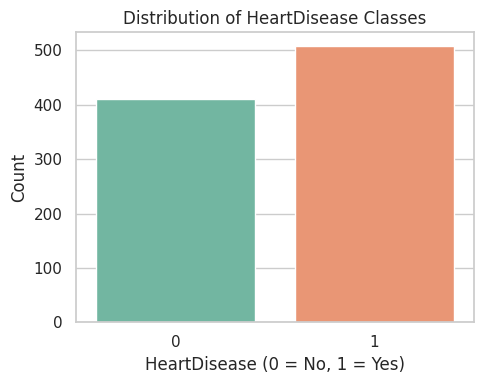


Class balance (%):
HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64


In [19]:
#Visualize Distribution of Classes for Target Variable
plt.figure(figsize=(5, 4))
sns.countplot(x=y, hue=y, palette="Set2", legend=False)
plt.title("Distribution of HeartDisease Classes")
plt.xlabel("HeartDisease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("class_distribution.png")
plt.show()

print("\nClass balance (%):")
print(y.value_counts(normalize=True) * 100)

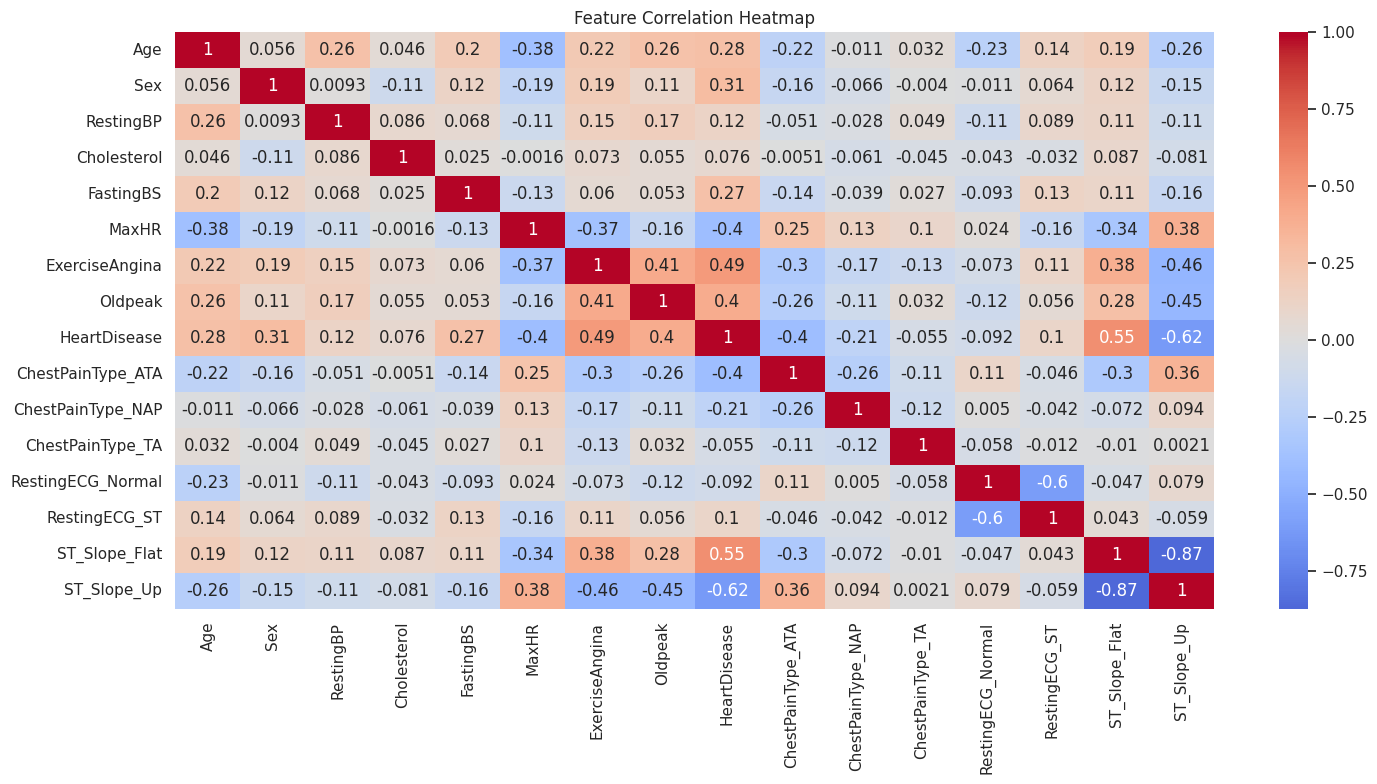

In [20]:
#Visualize Correlation Between Features
plt.figure(figsize=(15, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()

Based on the above heatmap, there are a few instances of moderate multicollinearity, most notably:
*   ExerciseAngina & Oldpeak - **0.41**
*   MaxHR & ST_Slope_Up - **0,38**
*   ExerciseAngina & ST_Slope_Flat - **0.38**
*   ChestPainType_ATA & ST_Slope_Up - **0.36**

In [21]:
#Feature Correlation to Target Variable, Sorted By Strength
target_corr = corr["HeartDisease"].drop("HeartDisease").sort_values(key=abs, ascending=False)
print("Feature correlation with HeartDisease (sorted by strength):")
print(target_corr)

Feature correlation with HeartDisease (sorted by strength):
ST_Slope_Up         -0.622164
ST_Slope_Flat        0.554134
ExerciseAngina       0.494282
Oldpeak              0.403951
ChestPainType_ATA   -0.401924
MaxHR               -0.400421
Sex                  0.305445
Age                  0.282039
FastingBS            0.267291
ChestPainType_NAP   -0.212964
RestingBP            0.117798
RestingECG_ST        0.102527
RestingECG_Normal   -0.091580
Cholesterol          0.076114
ChestPainType_TA    -0.054790
Name: HeartDisease, dtype: float64


Based on feature correlation with  heart disease, as shown above, the strongest correlations are:
*   ST_Slope_Up (**-0.622**)
*   ST_Slope_Flat (**0.554**)
*   ExerciseAngina (**0.494**)


While the weakest correlation is 'ChestPainType_TA' (**-0.055**)



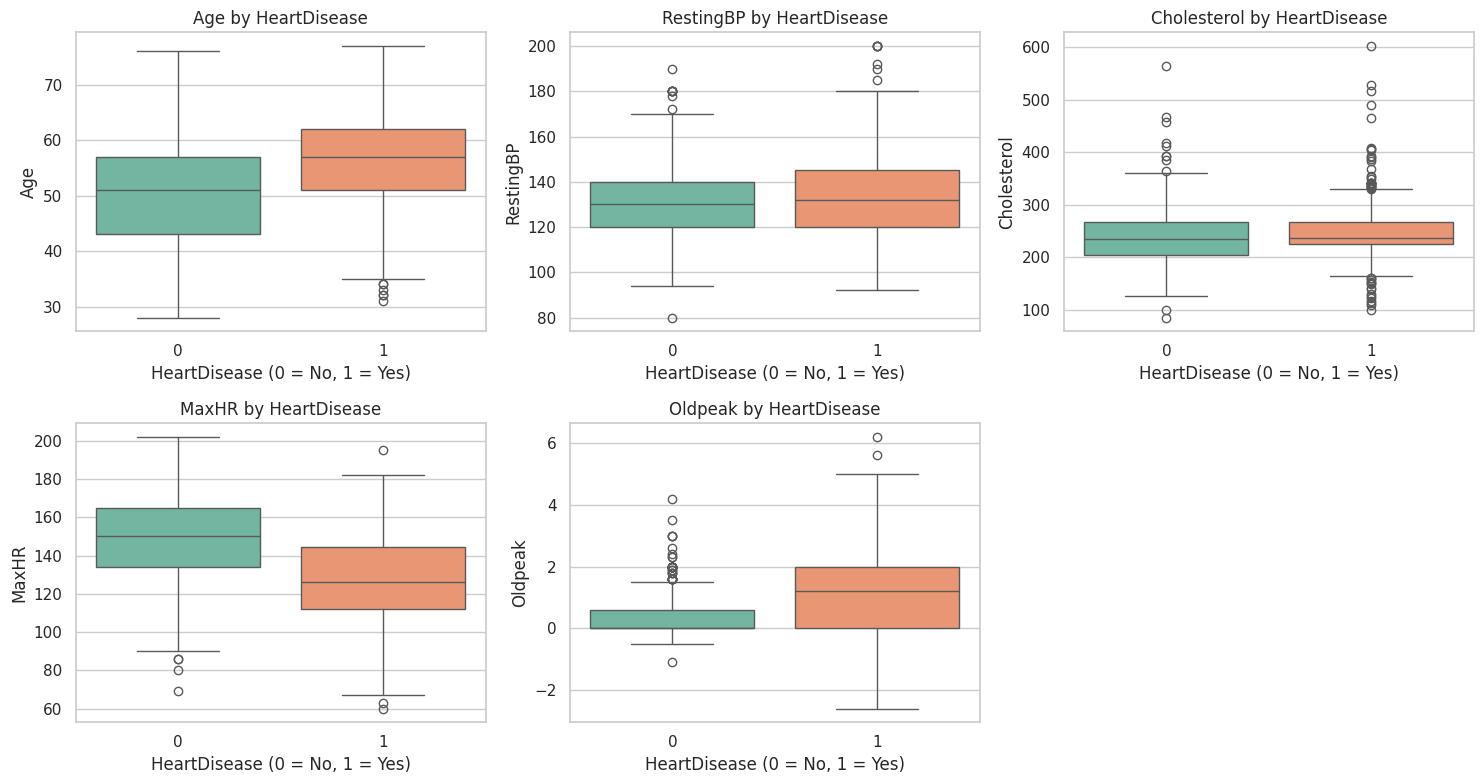

In [22]:
#Visualize Distributions of Key Numeric Features by Class
numeric_features = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_features):
    sns.boxplot(x=y, hue=y, y=df[col], ax=axes[i], palette="Set2", legend=False)
    axes[i].set_title(f"{col} by HeartDisease")
    axes[i].set_xlabel("HeartDisease (0 = No, 1 = Yes)")
fig.delaxes(axes[-1]) #Remove Unused Subplot
plt.tight_layout()
plt.savefig("numeric_features_by_class.png")
plt.show()

**Task 3: Model Implementation and Evaluation**

**Implementation Approach**

Prior to any model training, feature scaling will be done to ensure trained models do not over/under value any features. Logistic Regression models notably benefit from scaled features.

Model Selection - Logistic Regression & Random Forest
*   **Logistic Regression**: this is the natural baseline for binary classification as coefficients are directly interpretable & training is simple/straightforward
*   **Random Forest**: typically the strongest performer on tabular data and also indicates feature importances to compare against correlation analysis from EDA

Given that Logistic Regression models assume that features are on comparable scales, above noted scaling is crucial. While scaling is not required for Random Forest, using the same scaled data for each model keeps the pipeline simpler without impacting Random Forest performance.

`Feature Scaling`

In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

`Model Training`

In [24]:
#Train Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)
y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]

In [25]:
#Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

`Model Evaluation`

In [26]:
#Evaluate Both Models on the Same Metrics
def evaluate_model(name, y_true, y_pred, y_proba):
    print(f"\n{name}:")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.3f}")
    print(f"Precision: {precision_score(y_true, y_pred):.3f}")
    print(f"Recall: {recall_score(y_true, y_pred):.3f}")
    print(f"F1-score: {f1_score(y_true, y_pred):.3f}")
    print(f"ROC-AUC: {roc_auc_score(y_true, y_proba):.3f}")

evaluate_model("Logistic Regression", y_test, y_pred_log, y_proba_log)
evaluate_model("Random Forest", y_test, y_pred_rf, y_proba_rf)


Logistic Regression:
Accuracy: 0.891
Precision: 0.894
Recall: 0.912
F1-score: 0.903
ROC-AUC: 0.933

Random Forest:
Accuracy: 0.870
Precision: 0.882
Recall: 0.882
F1-score: 0.882
ROC-AUC: 0.933


**Task 4: Model Interpretation and Inference**

`Confusion Matrices`

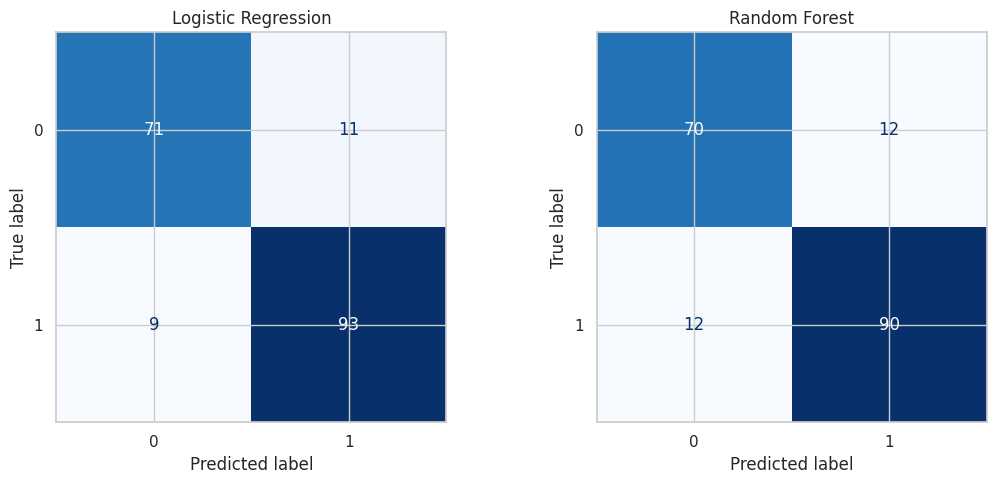

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Logistic Regression")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("Random Forest")
plt.tight_layout()
plt.savefig("confusion_matrices.png")
plt.show()

Logistic Regression edges out Random Forest on every metric except ROC-AUC, where they tie. The gap that matters most here is **recall**: Logistic Regression correctly identified 93 of 102 actual heart disease cases (9 false negatives), while Random Forest identified 90 of 102 (12 false negatives).

In a medical screening context, a false negative is generally more costly than a false positive, so the model with fewer false negatives has a real practical edge, not just a marginally better theoretical outcome

Contrary to initial assumptions, Logistic Regression outperforming Random Forest is note worthy though this does not lead to any meaninful implications.

`ROC Curves`

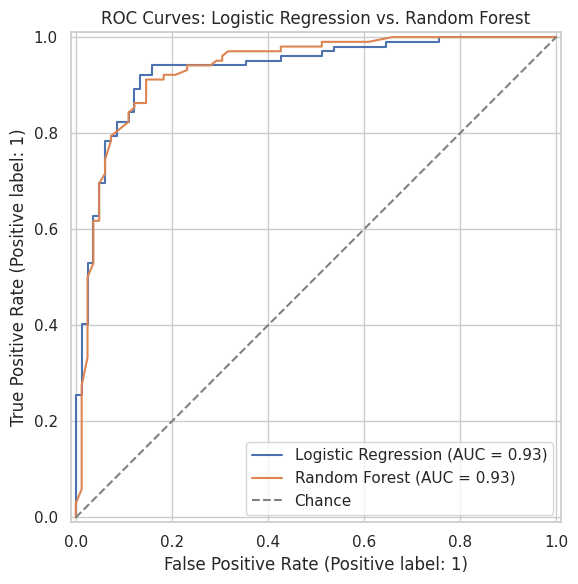

In [28]:
fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(y_test, y_proba_log, name="Logistic Regression", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba_rf, name="Random Forest", ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_title("ROC Curves: Logistic Regression vs. Random Forest")
ax.legend()
plt.tight_layout()
plt.savefig("roc_curves.png")
plt.show()

`Examine Feature Importance Versus Correlation`

In [29]:
#Examine Feature Importance vs Correlation
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Random Forest feature importances:")
print(importances)

Random Forest feature importances:
ST_Slope_Up          0.162409
ST_Slope_Flat        0.124261
Oldpeak              0.111103
MaxHR                0.108116
Cholesterol          0.085842
Age                  0.079385
ExerciseAngina       0.072762
RestingBP            0.070352
ChestPainType_ATA    0.045077
Sex                  0.037578
ChestPainType_NAP    0.033720
FastingBS            0.029408
RestingECG_Normal    0.018279
ChestPainType_TA     0.011666
RestingECG_ST        0.010043
dtype: float64


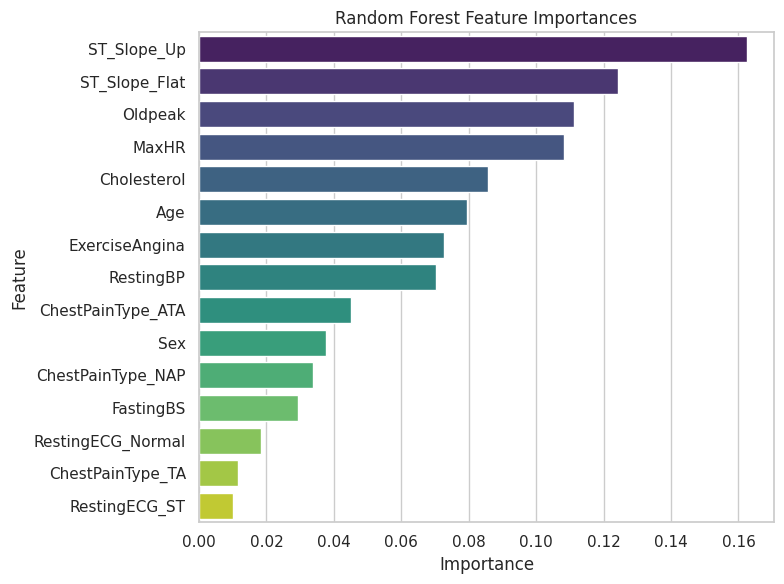

In [30]:
#Visualize Feature Importance vs Correlation
plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index,
            palette="viridis", legend=False)
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("rf_feature_importances.png")
plt.show()

Random Forest's top features (ST_Slope_Up, ST_Slope_Flat, Oldpeak, MaxHR) line up closely with the strongest absolute correlations to HeartDisease from the earlier created heatmap (ST_Slope_Up, ST_Slope_Flat, ExerciseAngina, Oldpeak, ChestPainType_ATA, MaxHR). That agreement across two independent methods is a good interpretability signal, suggesting that the model is picking up genuine relationships in the data rather than noise.

**Task 5: Deployment and Monitoring**

`Proposed Deployment Method`

Wrap the trained Logistic Regression model behind a lightweight REST API such as FastAPI or Flask, that accepts patient feature values as JSON and returns a prediction plus probability score. Serialize and ship the model together with the StandardScaler and LabelEncoder/one-hot column structure, since predictions are only valid if incoming data is transformed in accordance with training data.

The API would sit behind a container (Docker) so the environment stays consistent between training and serving, and could be deployed to a cloud service.

`Potential Deployment Issues`

**Preprocessing mismatch**

Should a new patient record come in with Cholesterol or RestingBP as 0, the production pipeline needs to apply the same "treat 0 as missing, impute" logic used in training, or predictions will be quietly wrong rather than erroring out.


**Schema drift**

Should the input source change column names, units, or category spellings (e.g., "M"/"F" becomes "Male"/"Female"), the encoders will silently mis-map values.


**Data drift over time**

The patient population feeding the model in production may differ from the training population (different age distribution, different hospital, different measurement equipment), which may degrade accuracy without any code changing.


**Class imbalance shift**

Should the real-world disease rate differ from the ~55/45 split in training, precision/recall trade-offs shift too, and the current decision threshold (0.5) may no longer be well-calibrated.

`Monitoring & Maintenance Strategies`

*   Log every prediction with its input features and confidence score, to facilitate retroactively auditting drift.
*   Track the distribution of incoming feature values over time and alert if they diverge meaningfully from the training distribution.
*   Where ground-truth diagnoses eventually become available (ex. confirmed later by a physician), periodically recompute accuracy/recall on real outcomes, not just at deployment time.
*   Set a retraining cadence or a performance-based trigger (ex. "retrain if recall on recent labeled data drops below 0.85").
*   Version the model and preprocessing pipeline together, so any retraining is fully reproducible and rollback is possible if a new version underperforms.

In [ ]:
#GitHub Repo: https://github.com/DDanso98/assignment-8.git